In [277]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

In [7]:
df=pd.read_csv(r"C:\Users\khare\Downloads\churn-competition-pdc\train.csv")
df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15642345.0,Ikedinachukwu,659.0,France,Male,42.0,7.0,0.00,2.0,1.0,0.0,184843.77,0.0
1,1,15765311.0,Zikoranachidimma,749.0,France,Male,29.0,9.0,0.00,2.0,1.0,0.0,162960.05,0.0
2,2,15727499.0,Rizzo,590.0,France,Female,37.0,2.0,0.00,2.0,0.0,1.0,131804.86,0.0
3,3,15701166.0,Chidimma,477.0,Germany,Male,44.0,8.0,141078.37,1.0,1.0,0.0,60778.11,1.0
4,4,15574554.0,Obialo,584.0,Spain,Female,31.0,6.0,0.00,2.0,1.0,0.0,136050.77,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,Maclean,644.0,France,Male,35.0,6.0,0.00,2.0,1.0,0.0,102517.84,0.0
14996,14996,15670562.0,Palermo,632.0,France,Female,27.0,8.0,0.00,2.0,1.0,0.0,55796.85,0.0
14997,14997,15734850.0,T'ao,611.0,Spain,Female,36.0,7.0,0.00,2.0,1.0,1.0,95864.50,0.0
14998,14998,15726791.0,Chukwuhaenye,635.0,France,Male,52.0,8.0,0.00,1.0,0.0,0.0,157959.02,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [11]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [13]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns

Index(['id', 'customerid', 'surname', 'creditscore', 'geography', 'gender',
       'age', 'tenure', 'balance', 'numofproducts', 'hascrcard',
       'isactivemember', 'estimatedsalary', 'exited'],
      dtype='object')

In [15]:
df["id"].is_unique

True

In [17]:
expected=pd.Series(range(len(df)))
(df["id"]==expected).all()

True

In [19]:
df["customerid"]

0        15642345.0
1        15765311.0
2        15727499.0
3        15701166.0
4        15574554.0
            ...    
14995    15714789.0
14996    15670562.0
14997    15734850.0
14998    15726791.0
14999    15679770.0
Name: customerid, Length: 15000, dtype: float64

In [21]:
df["customerid"].is_unique

False

In [23]:
df["customerid"].value_counts()[df["customerid"].value_counts()>1]

customerid
15691808.0    17
15798895.0    15
15572390.0    15
15682533.0    14
15690164.0    14
              ..
15592937.0     2
15770291.0     2
15672912.0     2
15682070.0     2
15577078.0     2
Name: count, Length: 3454, dtype: int64

In [25]:
df["surname"]=df["surname"].str.strip().str.lower()
df["surname"]

0           ikedinachukwu
1        zikoranachidimma
2                   rizzo
3                chidimma
4                  obialo
               ...       
14995             maclean
14996             palermo
14997                t'ao
14998        chukwuhaenye
14999              ch'ang
Name: surname, Length: 15000, dtype: object

In [27]:
valid_pattern=r"^[A-Za-z' -]+$"
invalid_surnames=df[~df["surname"].str.match(valid_pattern)]
invalid_surnames

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
9,9,15608916.0,y?,584.0,France,Female,38.0,2.0,0.00,2.0,1.0,1.0,1710.89,0.0
19,19,15583863.0,hs?,657.0,Germany,Male,37.0,1.0,131519.59,1.0,1.0,0.0,141798.98,1.0
27,27,15660301.0,hs?,611.0,Spain,Female,48.0,3.0,102773.15,1.0,0.0,0.0,108747.12,1.0
28,28,15597906.0,y?,841.0,Spain,Female,28.0,9.0,0.00,1.0,1.0,0.0,172576.43,1.0
46,46,15671162.0,hs?,562.0,Germany,Female,34.0,9.0,102025.32,2.0,0.0,1.0,138399.67,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14862,14862,15697310.0,hs?,649.0,Germany,Male,43.0,7.0,108822.40,1.0,1.0,0.0,48644.94,0.0
14879,14879,15694879.0,y?an,621.0,Spain,Female,32.0,1.0,0.00,2.0,0.0,1.0,140889.32,0.0
14896,14896,15587573.0,y?,718.0,France,Female,62.0,2.0,0.00,1.0,0.0,1.0,24506.95,0.0
14910,14910,15587712.0,k?,535.0,Germany,Female,46.0,6.0,151858.98,1.0,1.0,0.0,105986.01,1.0


In [29]:
df["surname_invalid"]=~df["surname"].str.match(valid_pattern)

In [31]:
df

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid
0,0,15642345.0,ikedinachukwu,659.0,France,Male,42.0,7.0,0.00,2.0,1.0,0.0,184843.77,0.0,False
1,1,15765311.0,zikoranachidimma,749.0,France,Male,29.0,9.0,0.00,2.0,1.0,0.0,162960.05,0.0,False
2,2,15727499.0,rizzo,590.0,France,Female,37.0,2.0,0.00,2.0,0.0,1.0,131804.86,0.0,False
3,3,15701166.0,chidimma,477.0,Germany,Male,44.0,8.0,141078.37,1.0,1.0,0.0,60778.11,1.0,False
4,4,15574554.0,obialo,584.0,Spain,Female,31.0,6.0,0.00,2.0,1.0,0.0,136050.77,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,maclean,644.0,France,Male,35.0,6.0,0.00,2.0,1.0,0.0,102517.84,0.0,False
14996,14996,15670562.0,palermo,632.0,France,Female,27.0,8.0,0.00,2.0,1.0,0.0,55796.85,0.0,False
14997,14997,15734850.0,t'ao,611.0,Spain,Female,36.0,7.0,0.00,2.0,1.0,1.0,95864.50,0.0,False
14998,14998,15726791.0,chukwuhaenye,635.0,France,Male,52.0,8.0,0.00,1.0,0.0,0.0,157959.02,1.0,False


In [33]:
df["customerid_duplicate"]=df["customerid"].duplicated(keep=False)
df

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate
0,0,15642345.0,ikedinachukwu,659.0,France,Male,42.0,7.0,0.00,2.0,1.0,0.0,184843.77,0.0,False,True
1,1,15765311.0,zikoranachidimma,749.0,France,Male,29.0,9.0,0.00,2.0,1.0,0.0,162960.05,0.0,False,True
2,2,15727499.0,rizzo,590.0,France,Female,37.0,2.0,0.00,2.0,0.0,1.0,131804.86,0.0,False,False
3,3,15701166.0,chidimma,477.0,Germany,Male,44.0,8.0,141078.37,1.0,1.0,0.0,60778.11,1.0,False,True
4,4,15574554.0,obialo,584.0,Spain,Female,31.0,6.0,0.00,2.0,1.0,0.0,136050.77,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,maclean,644.0,France,Male,35.0,6.0,0.00,2.0,1.0,0.0,102517.84,0.0,False,False
14996,14996,15670562.0,palermo,632.0,France,Female,27.0,8.0,0.00,2.0,1.0,0.0,55796.85,0.0,False,True
14997,14997,15734850.0,t'ao,611.0,Spain,Female,36.0,7.0,0.00,2.0,1.0,1.0,95864.50,0.0,False,True
14998,14998,15726791.0,chukwuhaenye,635.0,France,Male,52.0,8.0,0.00,1.0,0.0,0.0,157959.02,1.0,False,False


In [35]:
print(df["creditscore"].max())
print(df["creditscore"].min())

850.0
431.0


In [37]:
decimal_scores=df[df["creditscore"]%1!=0]
print(f"Rows with decimals:{len(decimal_scores)}")

Rows with decimals:0


In [39]:
df["creditscore"]=df["creditscore"].astype(int)

In [41]:
df["creditscore"].head(20)

0     659
1     749
2     590
3     477
4     584
5     719
6     583
7     596
8     663
9     584
10    681
11    561
12    589
13    543
14    521
15    509
16    756
17    491
18    684
19    657
Name: creditscore, dtype: int32

In [43]:
df["geography"].unique()

array(['France', 'Germany', 'Spain'], dtype=object)

In [45]:
df["geography"].value_counts()

geography
France     8980
Spain      3310
Germany    2710
Name: count, dtype: int64

In [47]:
print(df[~df["geography"].isin(["France","Spain","Germany"])])

Empty DataFrame
Columns: [id, customerid, surname, creditscore, geography, gender, age, tenure, balance, numofproducts, hascrcard, isactivemember, estimatedsalary, exited, surname_invalid, customerid_duplicate]
Index: []


In [49]:
df["geography"]=df["geography"].str.strip().str.title()

In [51]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [53]:
df["gender"]=df["gender"].str.strip().str.title()
df["gender"]

0          Male
1          Male
2        Female
3          Male
4        Female
          ...  
14995      Male
14996    Female
14997    Female
14998      Male
14999      Male
Name: gender, Length: 15000, dtype: object

In [55]:
df["age"].describe()

count    15000.000000
mean        37.895133
std          8.221961
min         18.000000
25%         32.000000
50%         37.000000
75%         42.000000
max         74.000000
Name: age, dtype: float64

In [57]:
df["age"]=df["age"].round().astype(int)
df["age"]

0        42
1        29
2        37
3        44
4        31
         ..
14995    35
14996    27
14997    36
14998    52
14999    32
Name: age, Length: 15000, dtype: int32

In [59]:
(df["tenure"]%1==0).all()

True

In [61]:
df["tenure"]=df["tenure"].astype(int)
df["tenure"]

0        7
1        9
2        2
3        8
4        6
        ..
14995    6
14996    8
14997    7
14998    8
14999    9
Name: tenure, Length: 15000, dtype: int32

In [63]:
df

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate
0,0,15642345.0,ikedinachukwu,659,France,Male,42,7,0.00,2.0,1.0,0.0,184843.77,0.0,False,True
1,1,15765311.0,zikoranachidimma,749,France,Male,29,9,0.00,2.0,1.0,0.0,162960.05,0.0,False,True
2,2,15727499.0,rizzo,590,France,Female,37,2,0.00,2.0,0.0,1.0,131804.86,0.0,False,False
3,3,15701166.0,chidimma,477,Germany,Male,44,8,141078.37,1.0,1.0,0.0,60778.11,1.0,False,True
4,4,15574554.0,obialo,584,Spain,Female,31,6,0.00,2.0,1.0,0.0,136050.77,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,maclean,644,France,Male,35,6,0.00,2.0,1.0,0.0,102517.84,0.0,False,False
14996,14996,15670562.0,palermo,632,France,Female,27,8,0.00,2.0,1.0,0.0,55796.85,0.0,False,True
14997,14997,15734850.0,t'ao,611,Spain,Female,36,7,0.00,2.0,1.0,1.0,95864.50,0.0,False,True
14998,14998,15726791.0,chukwuhaenye,635,France,Male,52,8,0.00,1.0,0.0,0.0,157959.02,1.0,False,False


In [65]:
df

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate
0,0,15642345.0,ikedinachukwu,659,France,Male,42,7,0.00,2.0,1.0,0.0,184843.77,0.0,False,True
1,1,15765311.0,zikoranachidimma,749,France,Male,29,9,0.00,2.0,1.0,0.0,162960.05,0.0,False,True
2,2,15727499.0,rizzo,590,France,Female,37,2,0.00,2.0,0.0,1.0,131804.86,0.0,False,False
3,3,15701166.0,chidimma,477,Germany,Male,44,8,141078.37,1.0,1.0,0.0,60778.11,1.0,False,True
4,4,15574554.0,obialo,584,Spain,Female,31,6,0.00,2.0,1.0,0.0,136050.77,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,maclean,644,France,Male,35,6,0.00,2.0,1.0,0.0,102517.84,0.0,False,False
14996,14996,15670562.0,palermo,632,France,Female,27,8,0.00,2.0,1.0,0.0,55796.85,0.0,False,True
14997,14997,15734850.0,t'ao,611,Spain,Female,36,7,0.00,2.0,1.0,1.0,95864.50,0.0,False,True
14998,14998,15726791.0,chukwuhaenye,635,France,Male,52,8,0.00,1.0,0.0,0.0,157959.02,1.0,False,False


In [67]:
(df["balance"]<0).any()

False

In [69]:
(df["numofproducts"]<0).any()

False

In [71]:
(df["numofproducts"]%1!=0).any()

False

In [73]:
df["numofproducts"].unique()

array([2., 1., 4., 3.])

In [75]:
df["numofproducts"].value_counts()

numofproducts
2.0    8262
1.0    6515
3.0     198
4.0      25
Name: count, dtype: int64

In [77]:
df["numofproducts"]=df["numofproducts"].astype(int)
df["numofproducts"]

0        2
1        2
2        2
3        1
4        2
        ..
14995    2
14996    2
14997    2
14998    1
14999    2
Name: numofproducts, Length: 15000, dtype: int32

In [79]:
df["hascrcard"].unique()

array([1., 0.])

In [81]:
df["hascrcard"]=df["hascrcard"].astype(int)
df["hascrcard"]

0        1
1        1
2        0
3        1
4        1
        ..
14995    1
14996    1
14997    1
14998    0
14999    1
Name: hascrcard, Length: 15000, dtype: int32

In [83]:
df["isactivemember"].unique()

array([0., 1.])

In [85]:
df["isactivemember"]=df["isactivemember"].astype(int)

In [87]:
df["estimatedsalary"].describe()

count     15000.000000
mean     117038.969929
std       45695.548784
min          11.580000
25%       82556.580000
50%      122268.750000
75%      155879.547500
max      199992.480000
Name: estimatedsalary, dtype: float64

In [89]:
df["exited"].unique()

array([0., 1.])

In [91]:
df["exited"]=df["exited"].astype(int)

In [93]:
df

,id,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate
0,0,15642345.0,ikedinachukwu,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True
1,1,15765311.0,zikoranachidimma,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True
2,2,15727499.0,rizzo,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False
3,3,15701166.0,chidimma,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True
4,4,15574554.0,obialo,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15714789.0,maclean,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False
14996,14996,15670562.0,palermo,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True
14997,14997,15734850.0,t'ao,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True
14998,14998,15726791.0,chukwuhaenye,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15000 non-null  int64  
 1   customerid            15000 non-null  float64
 2   surname               15000 non-null  object 
 3   creditscore           15000 non-null  int32  
 4   geography             15000 non-null  object 
 5   gender                15000 non-null  object 
 6   age                   15000 non-null  int32  
 7   tenure                15000 non-null  int32  
 8   balance               15000 non-null  float64
 9   numofproducts         15000 non-null  int32  
 10  hascrcard             15000 non-null  int32  
 11  isactivemember        15000 non-null  int32  
 12  estimatedsalary       15000 non-null  float64
 13  exited                15000 non-null  int32  
 14  surname_invalid       15000 non-null  bool   
 15  customerid_duplicat

In [97]:
df=df.astype({col:"int64" for col in df.select_dtypes(include="int").columns})

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15000 non-null  int64  
 1   customerid            15000 non-null  float64
 2   surname               15000 non-null  object 
 3   creditscore           15000 non-null  int64  
 4   geography             15000 non-null  object 
 5   gender                15000 non-null  object 
 6   age                   15000 non-null  int64  
 7   tenure                15000 non-null  int64  
 8   balance               15000 non-null  float64
 9   numofproducts         15000 non-null  int64  
 10  hascrcard             15000 non-null  int64  
 11  isactivemember        15000 non-null  int64  
 12  estimatedsalary       15000 non-null  float64
 13  exited                15000 non-null  int64  
 14  surname_invalid       15000 non-null  bool   
 15  customerid_duplicat

In [101]:
df=df.drop(columns=["id","customerid","surname"])

In [103]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False


In [105]:
df["creditscore"].describe()

count    15000.000000
mean       658.501533
std         73.266675
min        431.000000
25%        602.000000
50%        661.000000
75%        709.000000
max        850.000000
Name: creditscore, dtype: float64

<Axes: >

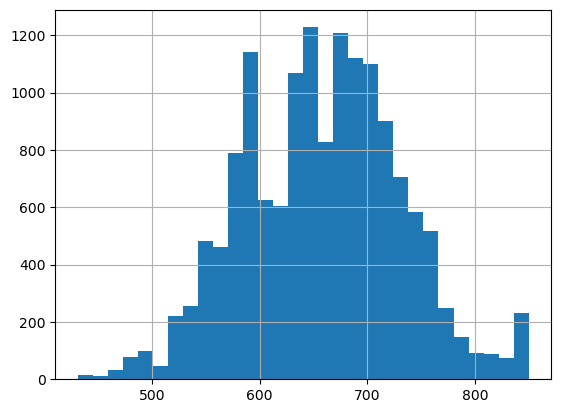

In [107]:
df["creditscore"].hist(bins=30)

<Axes: xlabel='creditscore'>

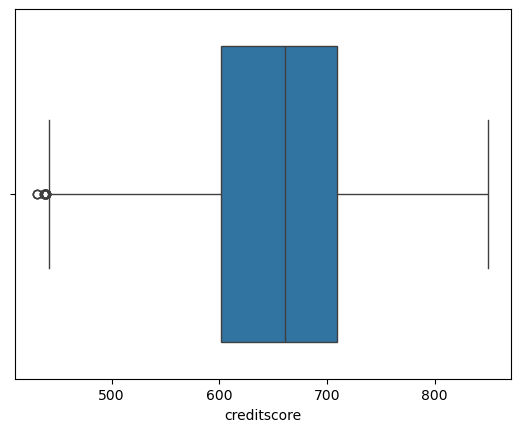

In [108]:
sns.boxplot(x=df["creditscore"])

In [110]:
df.groupby("exited")["creditscore"].mean()

exited
0    659.872144
1    653.231589
Name: creditscore, dtype: float64

C:\Users\khare\AppData\Local\Temp\ipykernel_33164\2874559778.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_creditband=df.groupby("creditscore_band")["exited"].mean()


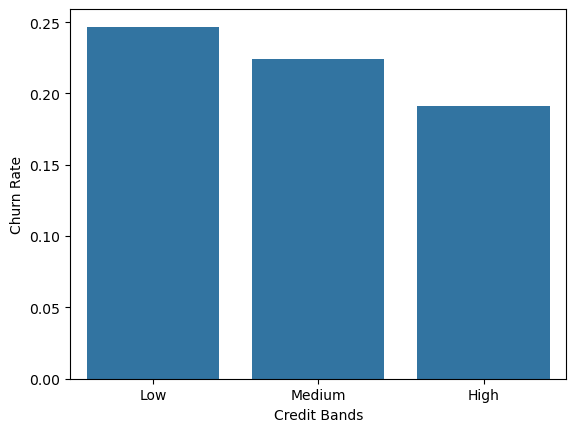

In [113]:
df["creditscore_band"]=pd.cut(df["creditscore"],
                             bins=[300,500,650,850],
                             labels=["Low","Medium","High"]
                       )
churn_by_creditband=df.groupby("creditscore_band")["exited"].mean()
sns.barplot(x=churn_by_creditband.index, y=churn_by_creditband.values)
plt.ylabel("Churn Rate")
plt.xlabel("Credit Bands")
plt.show()

In [115]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate,creditscore_band
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True,High
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True,High
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False,Medium
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True,Low
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False,Medium
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True,Medium
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True,Medium
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False,Medium


In [117]:
df["geography"].value_counts()

geography
France     8980
Spain      3310
Germany    2710
Name: count, dtype: int64

<Axes: xlabel='geography', ylabel='count'>

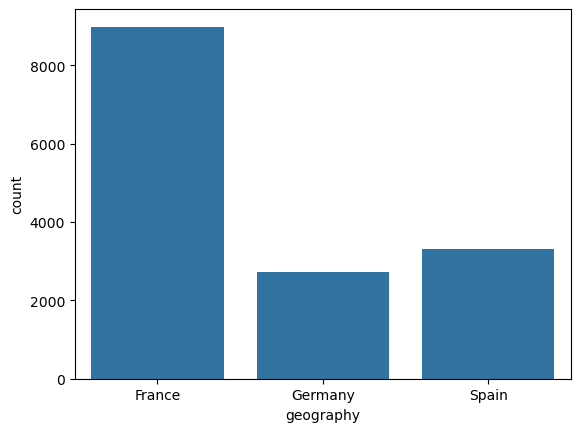

In [119]:
sns.countplot(x="geography", data=df)

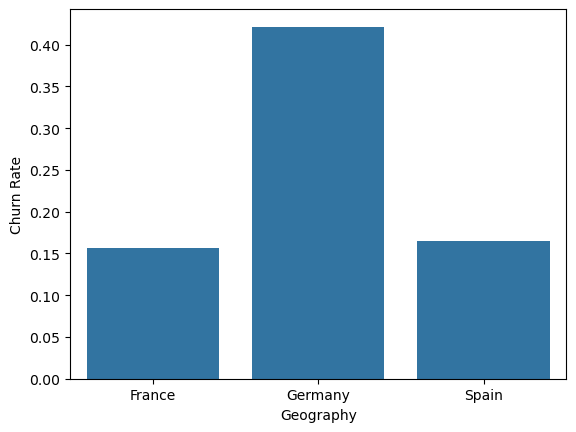

In [121]:
df.groupby("geography")["exited"].mean()
sns.barplot(x=(df.groupby("geography")["exited"].mean()).index, y=(df.groupby("geography")["exited"].mean()).values)
plt.ylabel("Churn Rate")
plt.xlabel("Geography")
plt.show()

In [123]:
df["gender"].value_counts()

gender
Male      8506
Female    6494
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

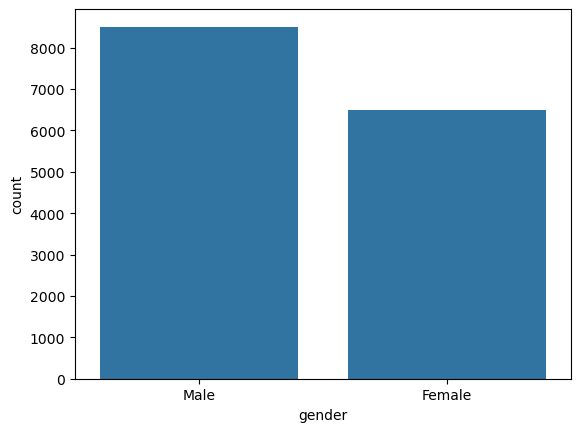

In [125]:
sns.countplot(x="gender", data=df)

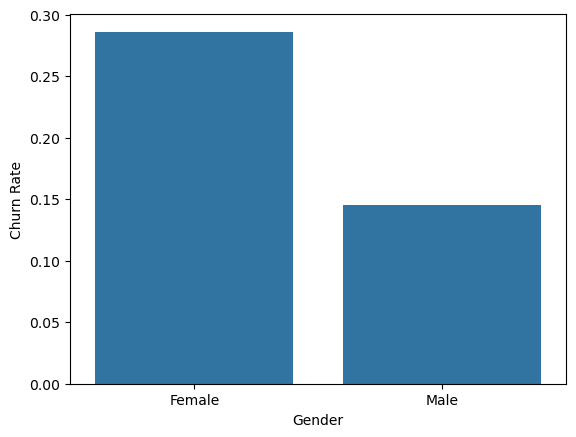

In [127]:
df.groupby("gender")["exited"].mean()
sns.barplot(x=(df.groupby("gender")["exited"].mean()).index, y=(df.groupby("gender")["exited"].mean()).values)
plt.ylabel("Churn Rate")
plt.xlabel("Gender")
plt.show()

In [129]:
df["age"].describe()

count    15000.000000
mean        37.895133
std          8.221961
min         18.000000
25%         32.000000
50%         37.000000
75%         42.000000
max         74.000000
Name: age, dtype: float64

<Axes: >

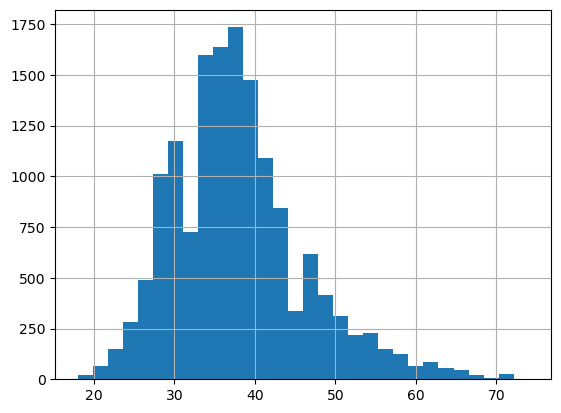

In [131]:
df["age"].hist(bins=30)

<Axes: xlabel='age'>

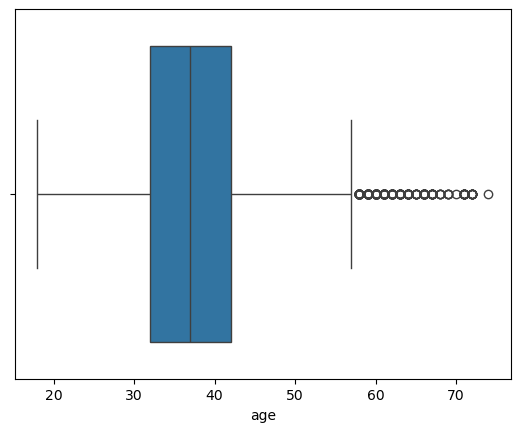

In [133]:
sns.boxplot(x=df["age"])

In [135]:
df.groupby("age")["exited"].mean()

age
18    0.000000
19    0.000000
20    0.000000
21    0.108696
22    0.093750
23    0.071429
24    0.088000
25    0.038462
26    0.036735
27    0.020576
28    0.060748
29    0.049743
30    0.028226
31    0.066372
32    0.055172
33    0.067445
34    0.034982
35    0.085396
36    0.072464
37    0.097272
38    0.091928
39    0.172932
40    0.200000
41    0.189597
42    0.319920
43    0.368764
44    0.311688
45    0.547337
46    0.572193
47    0.493827
48    0.694323
49    0.690217
50    0.630872
51    0.763975
52    0.824818
53    0.712500
54    0.760000
55    0.742574
56    0.800000
57    0.600000
58    0.582090
59    0.644068
60    0.666667
61    0.425532
62    0.525000
63    0.678571
64    0.333333
65    1.000000
66    0.194444
67    0.000000
68    1.000000
69    0.000000
70    1.000000
71    0.277778
72    0.100000
74    0.000000
Name: exited, dtype: float64

In [137]:
df["age_band"]=pd.cut(df["age"],
                     bins=[18,30,40,50,60,100],
                     labels=["18-29","30-39","40-49","50-59","60+"]
)

In [139]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate,creditscore_band,age_band
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True,High,40-49
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True,High,18-29
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False,Medium,30-39
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True,Low,40-49
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True,Medium,30-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False,Medium,30-39
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True,Medium,18-29
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True,Medium,30-39
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False,Medium,50-59


In [141]:
age_churn=df.groupby("age_band")["exited"].mean()
print(age_churn)

age_band
18-29    0.046763
30-39    0.093284
40-49    0.422743
50-59    0.730444
60+      0.394191
Name: exited, dtype: float64


C:\Users\khare\AppData\Local\Temp\ipykernel_33164\2368094464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn=df.groupby("age_band")["exited"].mean()


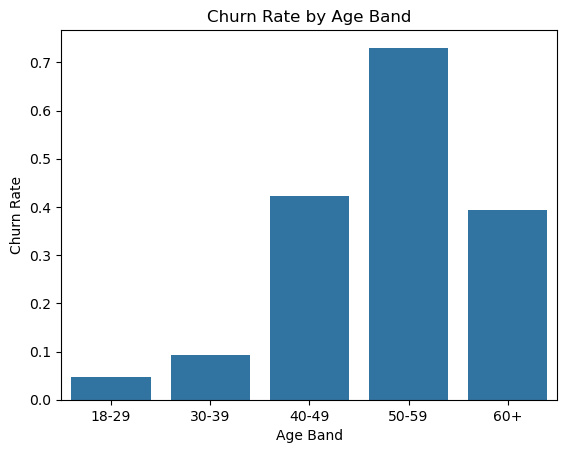

In [143]:
sns.barplot(x=age_churn.index, y=age_churn.values)
plt.ylabel("Churn Rate")
plt.xlabel("Age Band")
plt.title("Churn Rate by Age Band")
plt.show()

In [145]:
df["tenure"].describe()

count    15000.000000
mean         5.080733
std          2.785977
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: tenure, dtype: float64

<Axes: >

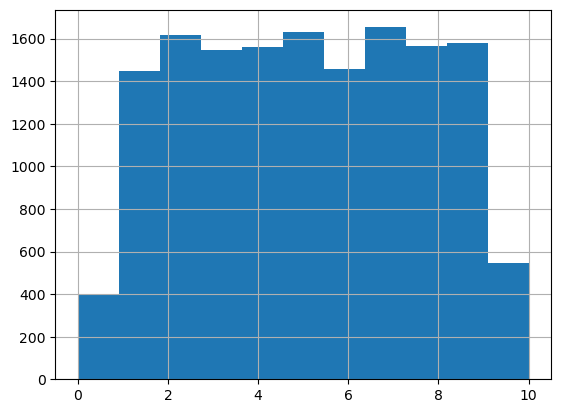

In [147]:
df["tenure"].hist(bins=11)

<Axes: xlabel='tenure'>

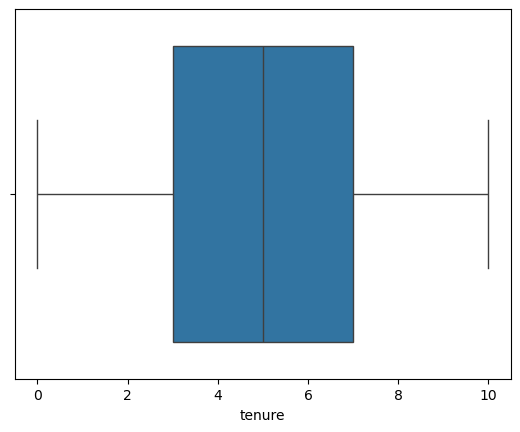

In [149]:
sns.boxplot(x=df["tenure"])

In [151]:
df.groupby("tenure")["exited"].mean()

tenure
0     0.250627
1     0.247586
2     0.193189
3     0.214748
4     0.200641
5     0.229589
6     0.206991
7     0.150635
8     0.187340
9     0.216593
10    0.219780
Name: exited, dtype: float64

In [153]:
df["tenure_band"]=pd.cut(
    df["tenure"],
    bins=[0,3,6,10],
    labels=["0-3","4-6","7-10"]
)

tenure
0     0.250627
1     0.247586
2     0.193189
3     0.214748
4     0.200641
5     0.229589
6     0.206991
7     0.150635
8     0.187340
9     0.216593
10    0.219780
Name: exited, dtype: float64


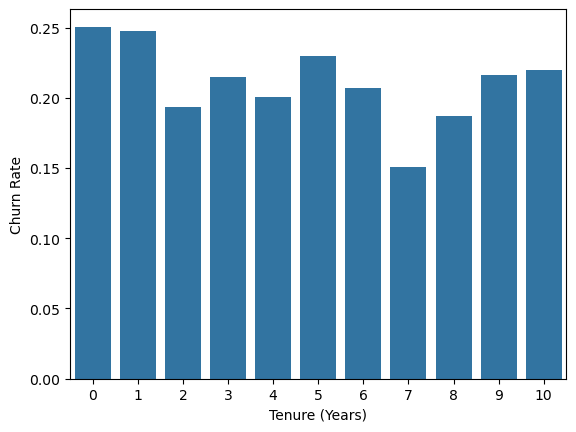

In [155]:
tenure_churn=df.groupby("tenure")["exited"].mean()
print(tenure_churn)
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.ylabel("Churn Rate")
plt.xlabel("Tenure (Years)")
plt.show()

In [157]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate,creditscore_band,age_band,tenure_band
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True,High,40-49,7-10
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True,High,18-29,7-10
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False,Medium,30-39,0-3
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True,Low,40-49,7-10
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True,Medium,30-39,4-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False,Medium,30-39,4-6
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True,Medium,18-29,7-10
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True,Medium,30-39,7-10
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False,Medium,50-59,7-10


tenure_band
0-3     0.217523
4-6     0.212780
7-10    0.187945
Name: exited, dtype: float64


C:\Users\khare\AppData\Local\Temp\ipykernel_33164\1185051698.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn=df.groupby("tenure_band")["exited"].mean()


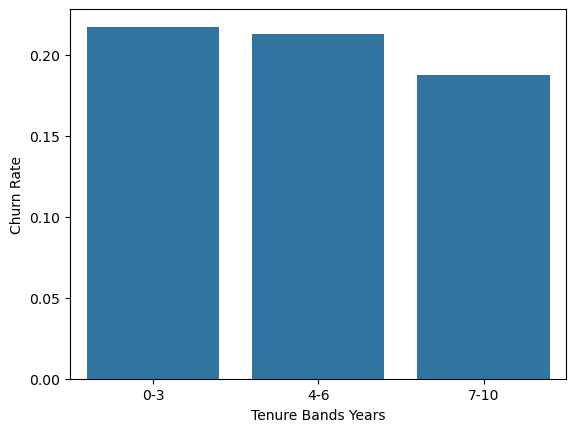

In [159]:
tenure_churn=df.groupby("tenure_band")["exited"].mean()
print(tenure_churn)
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Bands Years")
plt.show()

In [160]:
df["balance"].describe()

count     15000.000000
mean      43006.303826
std       59813.835788
min           0.000000
25%           0.000000
50%           0.000000
75%      110414.480000
max      187841.990000
Name: balance, dtype: float64

<Axes: >

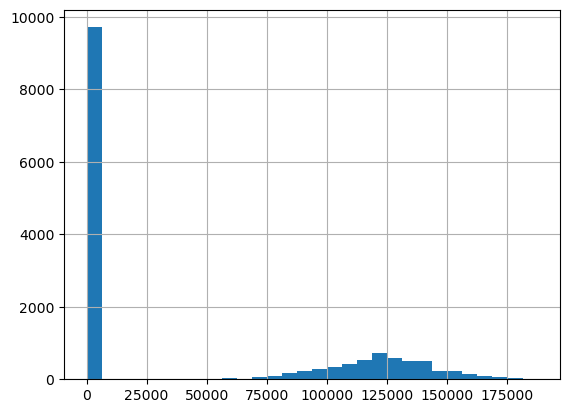

In [163]:
df["balance"].hist(bins=30)

<Axes: xlabel='balance'>

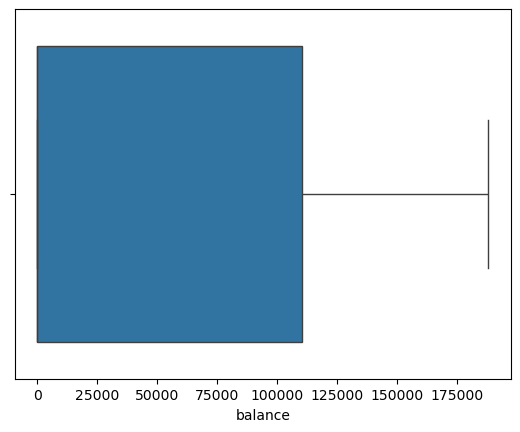

In [165]:
sns.boxplot(x=df["balance"])

In [167]:
df["has_balance"]=df["balance"]>0
print(df.groupby("has_balance")["exited"].mean())

has_balance
False    0.161828
True     0.288309
Name: exited, dtype: float64


In [169]:
df["balance_band"]=None

df.loc[df["balance"]==0, "balance_band"]="Zero"
df.loc[df["balance"]>0, "balance_band"]=pd.qcut(
    df.loc[df["balance"]>0, "balance"],
    q=3,
    labels=["Low","Medium","High"]
).astype(str)

In [171]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate,creditscore_band,age_band,tenure_band,has_balance,balance_band
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True,High,40-49,7-10,False,Zero
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True,High,18-29,7-10,False,Zero
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False,Medium,30-39,0-3,False,Zero
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True,Low,40-49,7-10,True,High
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True,Medium,30-39,4-6,False,Zero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False,Medium,30-39,4-6,False,Zero
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True,Medium,18-29,7-10,False,Zero
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True,Medium,30-39,7-10,False,Zero
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False,Medium,50-59,7-10,False,Zero


In [173]:
balance_churn=df.groupby("balance_band")["exited"].mean()

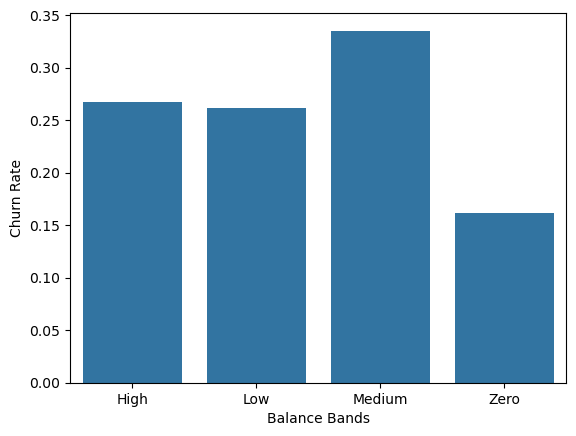

In [175]:
sns.barplot(x=balance_churn.index, y=balance_churn.values)
plt.ylabel("Churn Rate")
plt.xlabel("Balance Bands")
plt.show()

In [177]:
df["numofproducts"].value_counts()

numofproducts
2    8262
1    6515
3     198
4      25
Name: count, dtype: int64

In [179]:
df.groupby("numofproducts")["exited"].mean()

numofproducts
1    0.384804
2    0.045025
3    0.969697
4    1.000000
Name: exited, dtype: float64

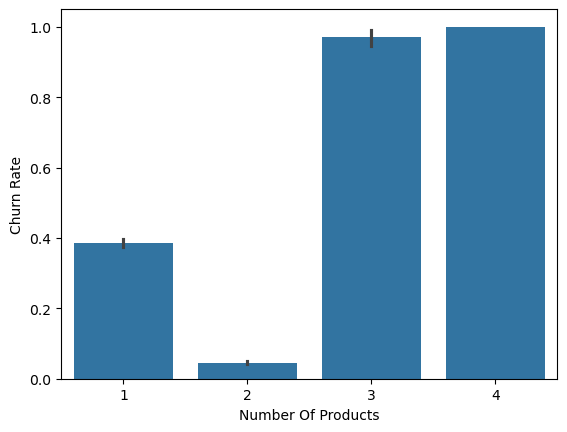

In [181]:
sns.barplot(x=df["numofproducts"], y=df["exited"])
plt.ylabel("Churn Rate")
plt.xlabel("Number Of Products")
plt.show()

In [183]:
df["num_products_bands"]=df["numofproducts"].replace({
    1:"One",
    2:"Two",
    3:"ThreePlus",
    4:"ThreePlus"
})
print(df["num_products_bands"].value_counts())

num_products_bands
Two          8262
One          6515
ThreePlus     223
Name: count, dtype: int64


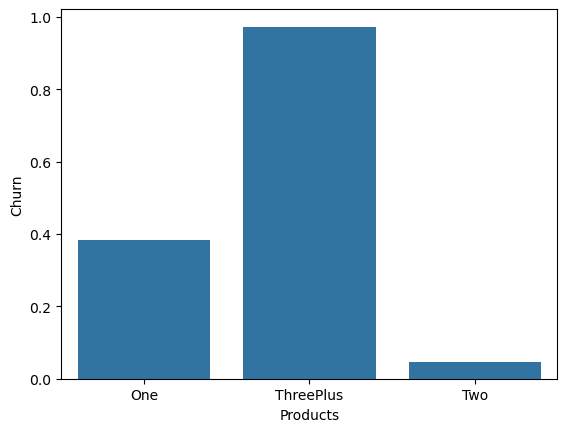

In [185]:
product_band_churn=df.groupby("num_products_bands")["exited"].mean()
sns.barplot(x=product_band_churn.index, y=product_band_churn.values)
plt.ylabel("Churn")
plt.xlabel("Products")
plt.show()

In [187]:
df["hascrcard"].value_counts()

hascrcard
1    11890
0     3110
Name: count, dtype: int64

In [189]:
df.groupby("hascrcard")["exited"].mean()

hascrcard
0    0.217042
1    0.203616
Name: exited, dtype: float64

numofproducts  hascrcard
1              0            0.393013
               1            0.382610
2              0            0.045373
               1            0.044937
3              0            0.962264
               1            0.972414
4              0            1.000000
               1            1.000000
Name: exited, dtype: float64


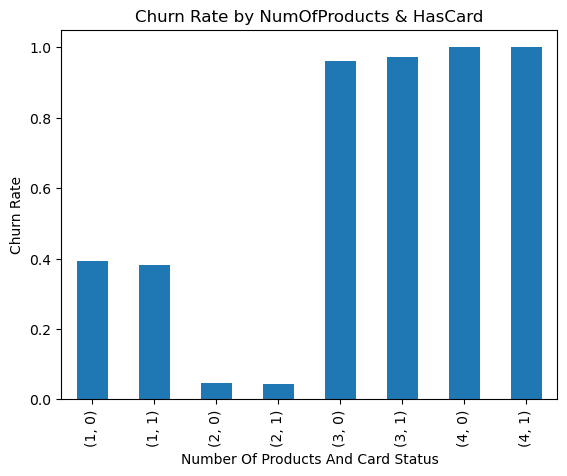

In [191]:
products_and_card=df.groupby(["numofproducts","hascrcard"])["exited"].mean()
print(products_and_card)
products_and_card.plot(kind="bar")
plt.ylabel("Churn Rate")
plt.xlabel("Number Of Products And Card Status")
plt.title("Churn Rate by NumOfProducts & HasCard")
plt.show()

In [193]:
df

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,surname_invalid,customerid_duplicate,creditscore_band,age_band,tenure_band,has_balance,balance_band,num_products_bands
0,659,France,Male,42,7,0.00,2,1,0,184843.77,0,False,True,High,40-49,7-10,False,Zero,Two
1,749,France,Male,29,9,0.00,2,1,0,162960.05,0,False,True,High,18-29,7-10,False,Zero,Two
2,590,France,Female,37,2,0.00,2,0,1,131804.86,0,False,False,Medium,30-39,0-3,False,Zero,Two
3,477,Germany,Male,44,8,141078.37,1,1,0,60778.11,1,False,True,Low,40-49,7-10,True,High,One
4,584,Spain,Female,31,6,0.00,2,1,0,136050.77,0,False,True,Medium,30-39,4-6,False,Zero,Two
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,644,France,Male,35,6,0.00,2,1,0,102517.84,0,False,False,Medium,30-39,4-6,False,Zero,Two
14996,632,France,Female,27,8,0.00,2,1,0,55796.85,0,False,True,Medium,18-29,7-10,False,Zero,Two
14997,611,Spain,Female,36,7,0.00,2,1,1,95864.50,0,False,True,Medium,30-39,7-10,False,Zero,Two
14998,635,France,Male,52,8,0.00,1,0,0,157959.02,1,False,False,Medium,50-59,7-10,False,Zero,One


In [195]:
df["isactivemember"].value_counts()

isactivemember
0    7619
1    7381
Name: count, dtype: int64

<Axes: >

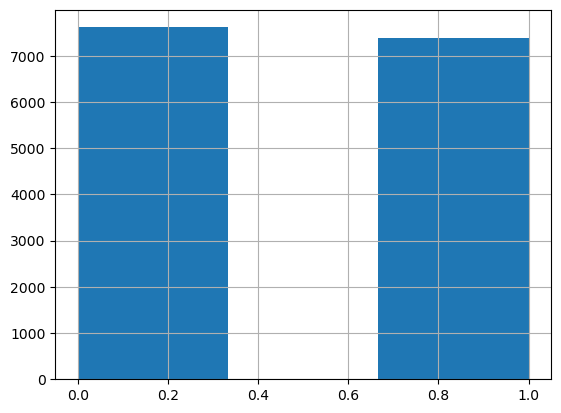

In [197]:
df["isactivemember"].hist(bins=3)

exited
0    0.543683
1    0.293605
Name: isactivemember, dtype: float64


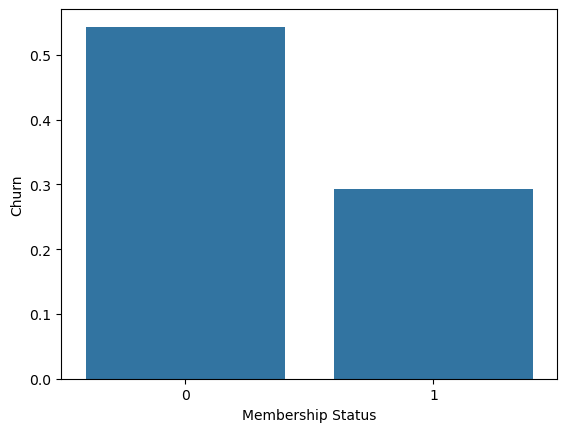

In [199]:
membership_churn=df.groupby("exited")["isactivemember"].mean()
print(membership_churn)
sns.barplot(x=membership_churn.index, y=membership_churn.values)
plt.ylabel("Churn")
plt.xlabel("Membership Status")
plt.show()

isactivemember
0    0.287046
1    0.123154
Name: exited, dtype: float64


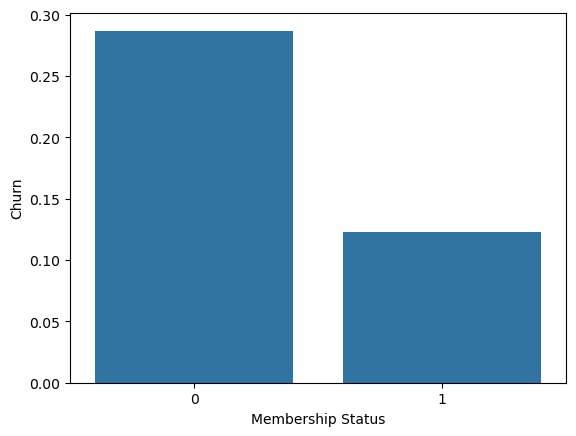

In [201]:
membership_churn=df.groupby("isactivemember")["exited"].mean()
print(membership_churn)
sns.barplot(x=membership_churn.index, y=membership_churn.values)
plt.ylabel("Churn")
plt.xlabel("Membership Status")
plt.show()
#strong predictor

In [203]:
df["estimatedsalary"].describe()

count     15000.000000
mean     117038.969929
std       45695.548784
min          11.580000
25%       82556.580000
50%      122268.750000
75%      155879.547500
max      199992.480000
Name: estimatedsalary, dtype: float64

<Axes: >

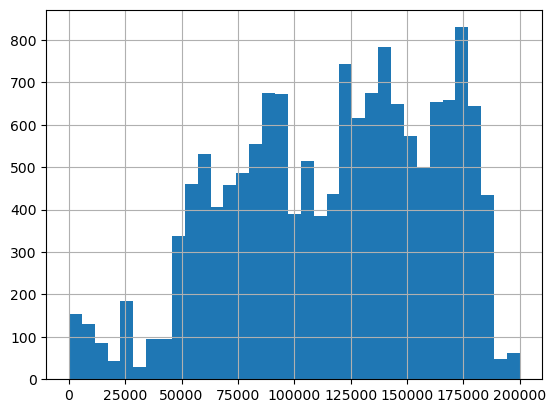

In [205]:
df["estimatedsalary"].hist(bins=35)

<Axes: xlabel='estimatedsalary'>

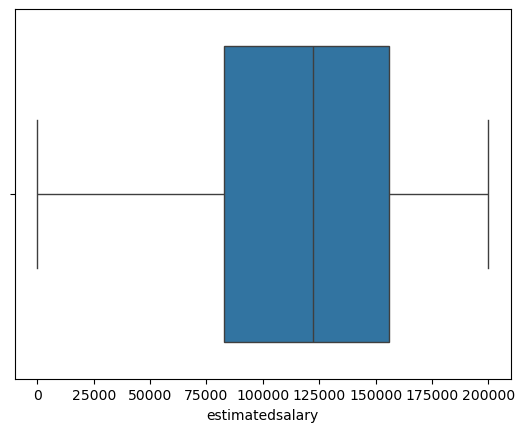

In [207]:
sns.boxplot(x="estimatedsalary", data=df)

In [209]:
churn_by_salary=df.groupby("estimatedsalary")["exited"].mean()
print(churn_by_salary)

estimatedsalary
11.58        0.5
447.73       1.0
479.54       0.0
582.53       0.0
582.59       0.0
            ... 
199693.84    0.0
199753.97    0.0
199808.10    1.0
199953.33    0.0
199992.48    0.0
Name: exited, Length: 6187, dtype: float64


In [211]:
df["salary_band_model"]=pd.qcut(
    df["estimatedsalary"],
    q=4,
    labels=["Q1","Q2","Q3","Q4"]
)

df["salary_band_business"]=pd.cut(
    df["estimatedsalary"],
    bins=[0,50000,100000,150000,200000],
    labels=["Low","Medium","High","Very High"],
    include_lowest=True
)

print(df["salary_band_model"].value_counts())
print(df["salary_band_business"].value_counts())

print(df.groupby("salary_band_model")["exited"].mean())
print(df.groupby("salary_band_business")["exited"].mean())

salary_band_model
Q2    3755
Q1    3750
Q4    3750
Q3    3745
Name: count, dtype: int64
salary_band_business
High         5167
Medium       4462
Very High    4287
Low          1084
Name: count, dtype: int64
salary_band_model
Q1    0.187467
Q2    0.203728
Q3    0.200801
Q4    0.233600
Name: exited, dtype: float64
salary_band_business
Low          0.198339
Medium       0.185119
High         0.208245
Very High    0.228365
Name: exited, dtype: float64


C:\Users\khare\AppData\Local\Temp\ipykernel_33164\504972427.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("salary_band_model")["exited"].mean())
C:\Users\khare\AppData\Local\Temp\ipykernel_33164\504972427.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("salary_band_business")["exited"].mean())


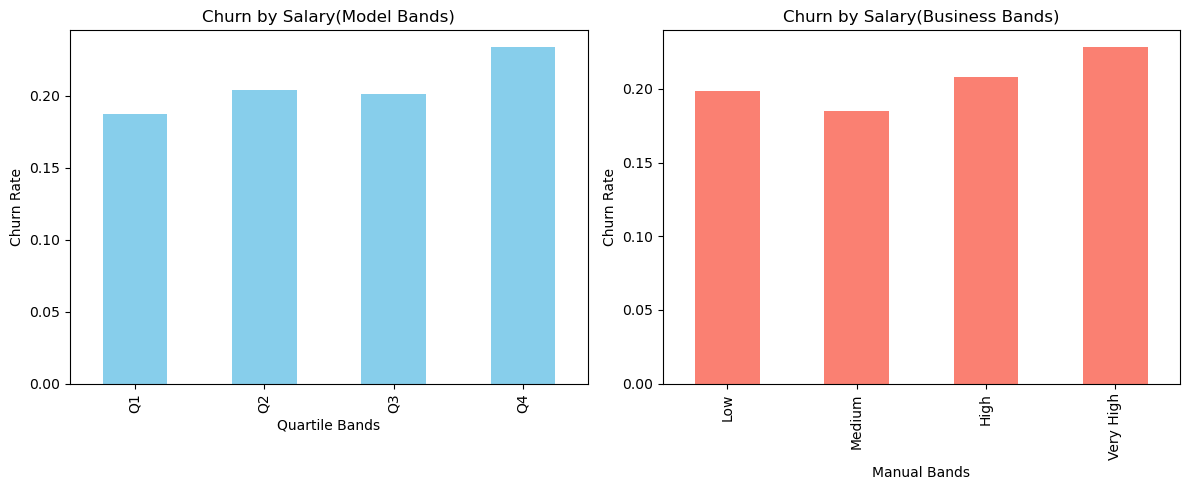

In [213]:
churn_model=df.groupby("salary_band_model", observed=True)["exited"].mean();
churn_business=df.groupby("salary_band_business", observed=True)["exited"].mean();
fig, axes=plt.subplots(1,2,figsize=(12,5))
churn_model.plot(kind="bar", ax=axes[0], color="skyblue")
axes[0].set_title("Churn by Salary(Model Bands)")
axes[0].set_ylabel("Churn Rate")
axes[0].set_xlabel("Quartile Bands")

churn_business.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Churn by Salary(Business Bands)")
axes[1].set_ylabel("Churn Rate")
axes[1].set_xlabel("Manual Bands")

plt.tight_layout()
plt.show()

In [215]:
df["exited"].value_counts()

exited
0    11904
1     3096
Name: count, dtype: int64

In [217]:
#Strong Predictors on the basis of EDA - 
#Weak- Creditscore, EstimatedSalary, HasCrCard, Tenure
#Strong- Geography, Gender, Age, Balance,Isactivemember, Numberofproducts

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   creditscore           15000 non-null  int64   
 1   geography             15000 non-null  object  
 2   gender                15000 non-null  object  
 3   age                   15000 non-null  int64   
 4   tenure                15000 non-null  int64   
 5   balance               15000 non-null  float64 
 6   numofproducts         15000 non-null  int64   
 7   hascrcard             15000 non-null  int64   
 8   isactivemember        15000 non-null  int64   
 9   estimatedsalary       15000 non-null  float64 
 10  exited                15000 non-null  int64   
 11  surname_invalid       15000 non-null  bool    
 12  customerid_duplicate  15000 non-null  bool    
 13  creditscore_band      15000 non-null  category
 14  age_band              14992 non-null  category
 15  te

In [221]:
#Split data (preserving churn ratio with stratify)
X=df.drop("exited", axis=1)
y=df["exited"]
categorical_cols=X.select_dtypes(include=["object","category"]).columns.tolist()
bool_cols=X.select_dtypes(include=["bool"]).columns.tolist()
numeric_cols=X.select_dtypes(include=["int64","float64"]).columns.tolist()

preprocessor=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num",StandardScaler(),numeric_cols+bool_cols)
    ]
)

X_train, X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.2, stratify=y, random_state=42
)

In [223]:
#Logistic Regerssion
log_reg=Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred_lr))

Logistic Regression ROC-AUC: 0.9245738510108635
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      2381
           1       0.60      0.83      0.69       619

    accuracy                           0.85      3000
   macro avg       0.77      0.84      0.80      3000
weighted avg       0.88      0.85      0.86      3000



In [225]:
rf=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])
rf.fit(X_train, y_train)
y_pred_rf=rf.predict(X_test)

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.9195027408014036
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2381
           1       0.80      0.63      0.71       619

    accuracy                           0.89      3000
   macro avg       0.86      0.80      0.82      3000
weighted avg       0.89      0.89      0.89      3000



In [227]:
#Crosstab Churn Rates
ct=pd.crosstab(df["numofproducts"],df["isactivemember"],values=df["exited"], aggfunc="mean").round(3)
print(ct)

isactivemember      0      1
numofproducts               
1               0.494  0.249
2               0.068  0.025
3               0.977  0.957
4               1.000  1.000


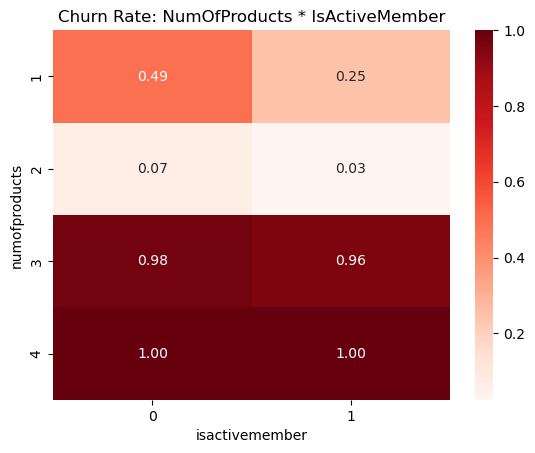

In [229]:
sns.heatmap(ct, annot=True, cmap="Reds", fmt=".2f")
plt.title("Churn Rate: NumOfProducts * IsActiveMember")
plt.show()

In [231]:
ct=pd.crosstab(df["geography"], df["balance_band"], values=df["exited"], aggfunc="mean").round(3)
print(ct)

balance_band   High    Low  Medium   Zero
geography                                
France        0.177  0.133   0.151  0.158
Germany       0.368  0.408   0.479  0.000
Spain         0.159  0.101   0.144  0.173


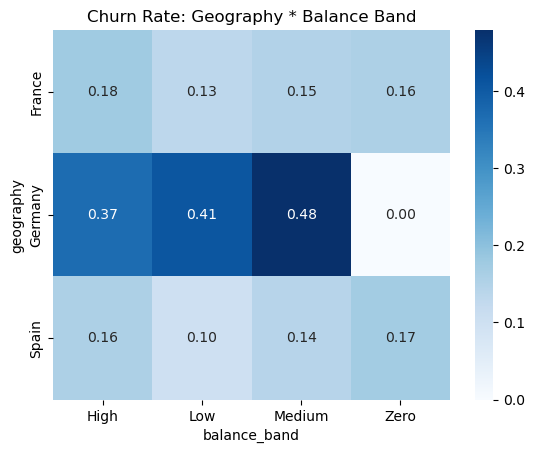

In [233]:
sns.heatmap(ct,annot=True,cmap="Blues", fmt="0.2f")
plt.title("Churn Rate: Geography * Balance Band")
plt.show()

isactivemember      0      1
age_band                    
18-29           0.068  0.027
30-39           0.134  0.055
40-49           0.530  0.278
50-59           0.942  0.492
60+             0.893  0.169


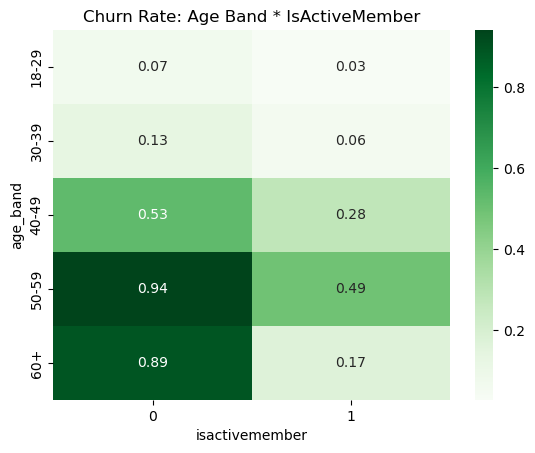

In [235]:
ct=pd.crosstab(df["age_band"], df["isactivemember"], values=df["exited"], aggfunc="mean").round(3)
print(ct)

sns.heatmap(ct, annot=True, cmap="Greens", fmt="0.2f")
plt.title("Churn Rate: Age Band * IsActiveMember")
plt.show()

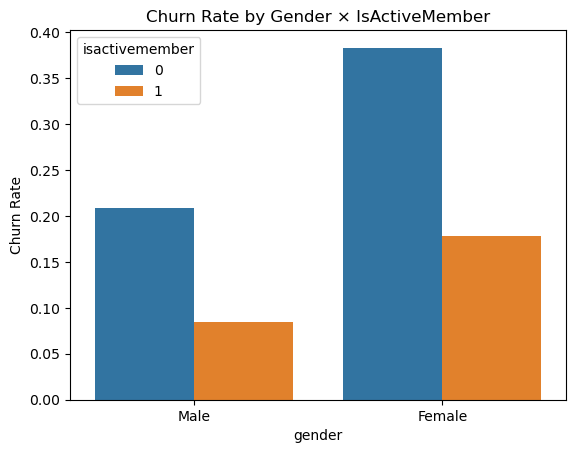

In [237]:
sns.barplot(
    x="gender", 
    y="exited", 
    hue="isactivemember", 
    data=df, 
    estimator="mean", 
    errorbar=None
)
plt.title("Churn Rate by Gender × IsActiveMember")
plt.ylabel("Churn Rate")
plt.show()

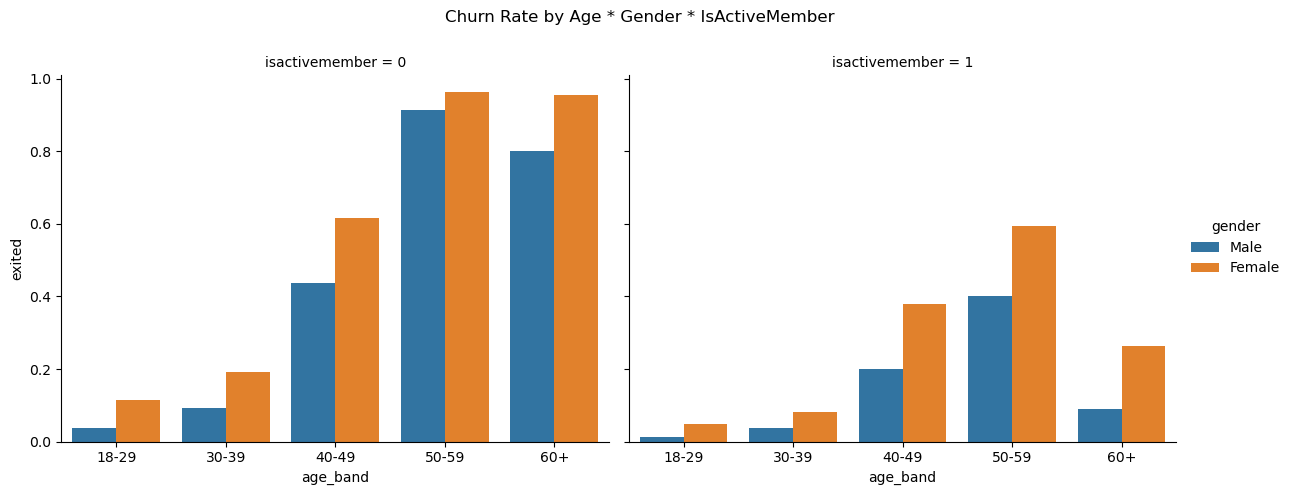

In [239]:
#3way grouped Barplot
sns.catplot(
    x="age_band",
    y="exited",
    hue="gender",
    col="isactivemember",
    data=df,
    kind="bar",
    estimator="mean",
    errorbar=None,
    height=5,
    aspect=1.2
)

plt.subplots_adjust(top=0.85)
plt.suptitle("Churn Rate by Age * Gender * IsActiveMember")
plt.show()

In [241]:
lr_model=log_reg.named_steps['model']
feature_names=preprocessor.get_feature_names_out()
coeffs=lr_model.coef_[0]
odds_ratios=np.exp(coeffs)
coef_df=pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":coeffs,
    "Odds_Ratio":odds_ratios
}).sort_values(by="Odds_Ratio", ascending=False)

print(coef_df.head(10))
print(coef_df.tail(10))

                              Feature  Coefficient  Odds_Ratio
0              cat__geography_Germany     2.003421    7.414377
16  cat__num_products_bands_ThreePlus     1.889803    6.618066
25                           num__age     0.974113    2.648817
7                 cat__age_band_50-59     0.821746    2.274468
15             cat__balance_band_Zero     0.708886    2.031726
6                 cat__age_band_40-49     0.603519    1.828542
14           cat__balance_band_Medium     0.516443    1.676055
3           cat__creditscore_band_Low     0.495713    1.641669
28                 num__numofproducts     0.428890    1.535552
27                       num__balance     0.340829    1.406113
                                Feature  Coefficient  Odds_Ratio
22     cat__salary_band_business_Medium    -0.248961    0.779611
5                   cat__age_band_30-39    -0.269485    0.763773
21        cat__salary_band_business_Low    -0.296988    0.743053
23  cat__salary_band_business_Very High    -0.3

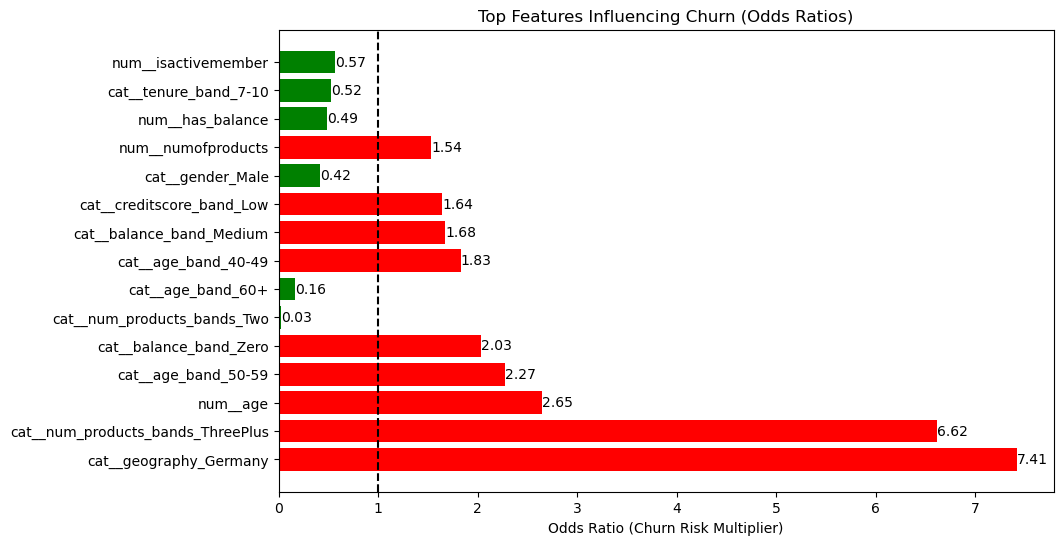

In [243]:
coef_df['EffectStrength']=abs(coef_df['Odds_Ratio']-1)
coef_df_sorted=coef_df.sort_values(by='EffectStrength', ascending=False)
top_features=coef_df_sorted.head(15)

plt.figure(figsize=(10,6))
bars=plt.barh(top_features['Feature'], top_features['Odds_Ratio'], color=[
    'red' if x>1 else 'green' for x in top_features['Odds_Ratio']
])

plt.axvline(x=1, color='black', linestyle='--')
plt.xlabel("Odds Ratio (Churn Risk Multiplier)")
plt.title("Top Features Influencing Churn (Odds Ratios)")

for bar, val in zip(bars, top_features['Odds_Ratio']):
    plt.text(bar.get_width(),bar.get_y()+bar.get_height()/2, f"{val:.2f}", va='center')

plt.show()

                                Feature  Importance
25                             num__age    0.185807
17          cat__num_products_bands_Two    0.122791
28                   num__numofproducts    0.102201
31                 num__estimatedsalary    0.077324
24                     num__creditscore    0.073697
27                         num__balance    0.044144
26                          num__tenure    0.043217
5                   cat__age_band_30-39    0.037446
30                  num__isactivemember    0.031649
6                   cat__age_band_40-49    0.028717
0                cat__geography_Germany    0.027746
7                   cat__age_band_50-59    0.024851
2                      cat__gender_Male    0.024515
16    cat__num_products_bands_ThreePlus    0.016747
1                  cat__geography_Spain    0.012546
29                       num__hascrcard    0.011970
4          cat__creditscore_band_Medium    0.011624
33            num__customerid_duplicate    0.011621
34          

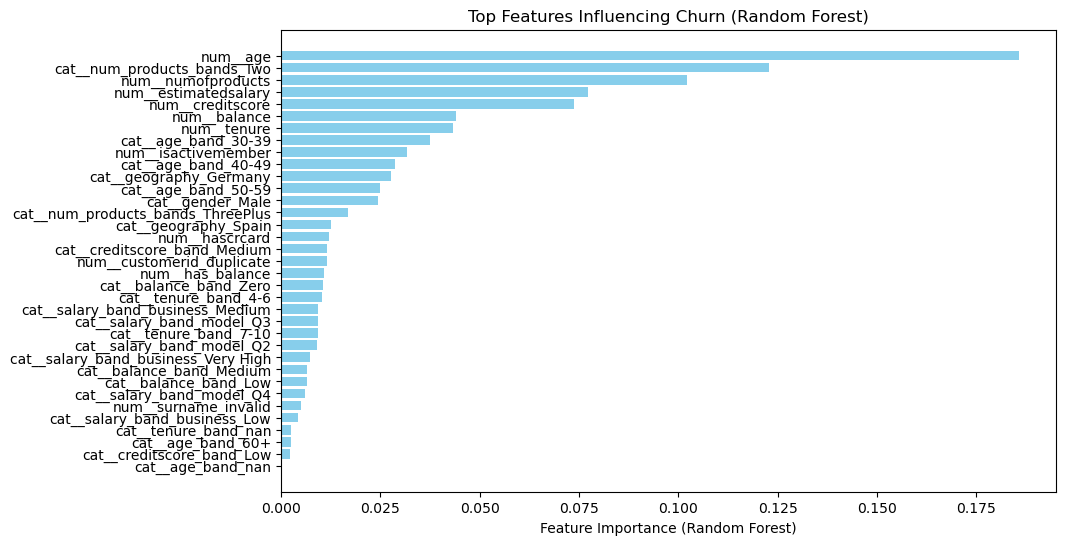

In [245]:
rf_model=rf.named_steps['model']
importance=rf_model.feature_importances_
feature_names=preprocessor.get_feature_names_out()

rf_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
}).sort_values(by="Importance", ascending=False)

print(rf_df)

top_features=rf_df
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel("Feature Importance (Random Forest)")
plt.title("Top Features Influencing Churn (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [247]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include=['object','category','bool'])),
        ('num', StandardScaler(),
         make_column_selector(dtype_include='number'))
    ]
)

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear', 'saga']
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best Parameters:", log_reg_grid.best_params_)
print("Best F1 Score:", log_reg_grid.best_score_)

Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'saga'}
Best F1 Score: 0.7151729898092188


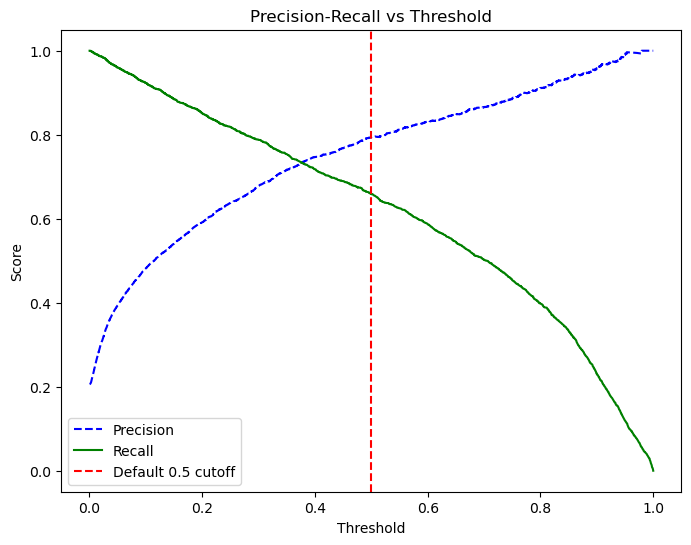

Best Threshold: 0.3459643324992933
Precision: 0.7138508371385084
Recall: 0.7573677836092046
F1 Score: 0.7349657198824681


In [248]:
#Predicted Probabilities
y_probs=log_reg_grid.predict_proba(X_train)[:,1]
precisions, recalls, thresholds=precision_recall_curve(y_train,y_probs)
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.axvline(x=0.5, color="red", linestyle="--", label="Default 0.5 cutoff")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1 Score:", f1_scores[best_idx])

In [251]:
y_probs = log_reg.predict_proba(X_train)[:,1]
best_threshold = 0.3459643324992933
y_pred_custom = (y_probs >= best_threshold).astype(int)
print(classification_report(y_train, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86      9523
           1       0.51      0.91      0.65      2477

    accuracy                           0.80     12000
   macro avg       0.74      0.84      0.76     12000
weighted avg       0.87      0.80      0.82     12000



In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   creditscore           15000 non-null  int64   
 1   geography             15000 non-null  object  
 2   gender                15000 non-null  object  
 3   age                   15000 non-null  int64   
 4   tenure                15000 non-null  int64   
 5   balance               15000 non-null  float64 
 6   numofproducts         15000 non-null  int64   
 7   hascrcard             15000 non-null  int64   
 8   isactivemember        15000 non-null  int64   
 9   estimatedsalary       15000 non-null  float64 
 10  exited                15000 non-null  int64   
 11  surname_invalid       15000 non-null  bool    
 12  customerid_duplicate  15000 non-null  bool    
 13  creditscore_band      15000 non-null  category
 14  age_band              14992 non-null  category
 15  te

In [255]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include='category')),

        ('obj', OneHotEncoder(handle_unknown='ignore'),
        make_column_selector(dtype_include='object')),

        ('bool', OneHotEncoder(handle_unknown='ignore'),
        make_column_selector(dtype_include='bool')),

        ('num', StandardScaler(),
         make_column_selector(dtype_include='number'))
    ]
)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
param_dist = {
    'model__n_estimators': np.arange(100, 1000, 100),
    'model__max_depth': [None, 10, 20, 30, 40, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}
rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=50,              
    cv=3,                  
    scoring='f1',           
    random_state=42,
    n_jobs=-1              
)
rf_random.fit(X_train, y_train)
print("Best Parameters:", rf_random.best_params_)
print("Best F1 Score:", rf_random.best_score_)

Best Parameters: {'model__n_estimators': 600, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best F1 Score: 0.7097025090666925


In [257]:
param_grid = {
    'model__n_estimators': [500, 600, 700],
    'model__max_depth': [15, 20, 25],
    'model__min_samples_split': [4, 5, 6],
    'model__min_samples_leaf': [3, 4, 5],
    'model__max_features': ['sqrt']
}
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print("Best Parameters (Grid):", rf_grid.best_params_)
print("Best F1 Score (Grid):", rf_grid.best_score_)

Best Parameters (Grid): {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 4, 'model__n_estimators': 600}
Best F1 Score (Grid): 0.7097025090666925


In [259]:
y_probs = rf_grid.best_estimator_.predict_proba(X_train)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1 Score:", f1_scores[best_idx])

Best Threshold: 0.3073437536645999
Precision: 0.762427151182722
Recall: 0.8978603148970529
F1 Score: 0.8246199480904709


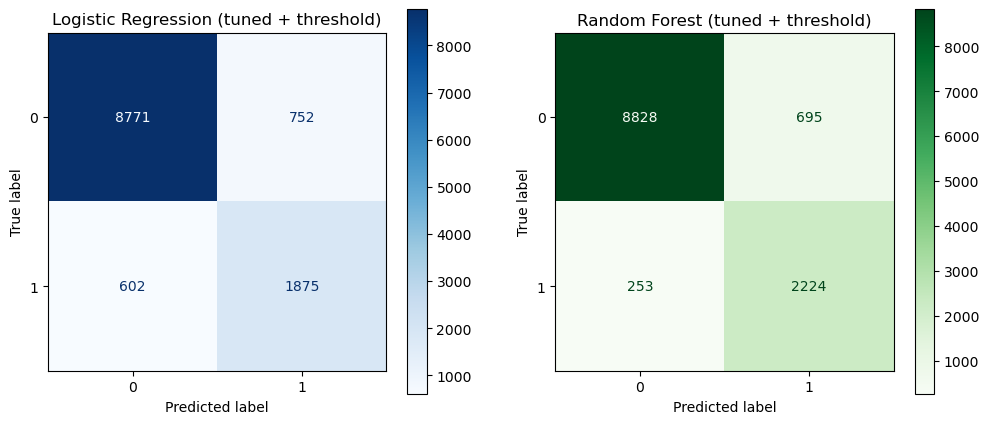

In [261]:
y_probs_lr = log_reg_grid.best_estimator_.predict_proba(X_train)[:,1]
y_pred_lr = (y_probs_lr >= 0.346).astype(int)

y_probs_rf = rf_grid.best_estimator_.predict_proba(X_train)[:,1]
y_pred_rf = (y_probs_rf >= 0.307).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_lr)).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression (tuned + threshold)")
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_rf)).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Random Forest (tuned + threshold)")

plt.show()

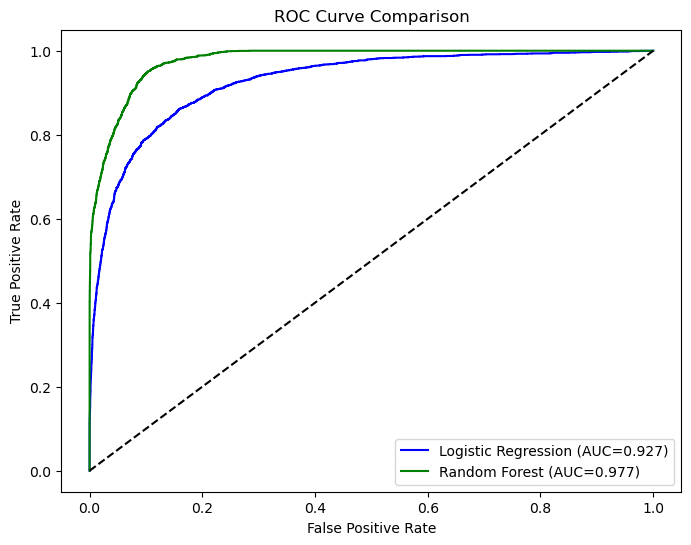

In [263]:
fpr_lr, tpr_lr, _ = roc_curve(y_train, y_probs_lr)
auc_lr = roc_auc_score(y_train, y_probs_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_train, y_probs_rf)
auc_rf = roc_auc_score(y_train, y_probs_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})", color="blue")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})", color="green")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

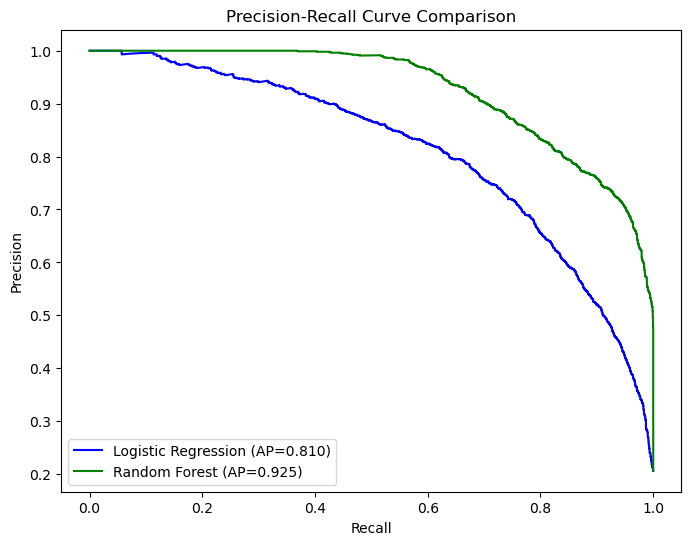

In [265]:
prec_lr, rec_lr, _ = precision_recall_curve(y_train, y_probs_lr)
ap_lr = average_precision_score(y_train, y_probs_lr)

prec_rf, rec_rf, _ = precision_recall_curve(y_train, y_probs_rf)
ap_rf = average_precision_score(y_train, y_probs_rf)

plt.figure(figsize=(8,6))
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP={ap_lr:.3f})", color="blue")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP={ap_rf:.3f})", color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

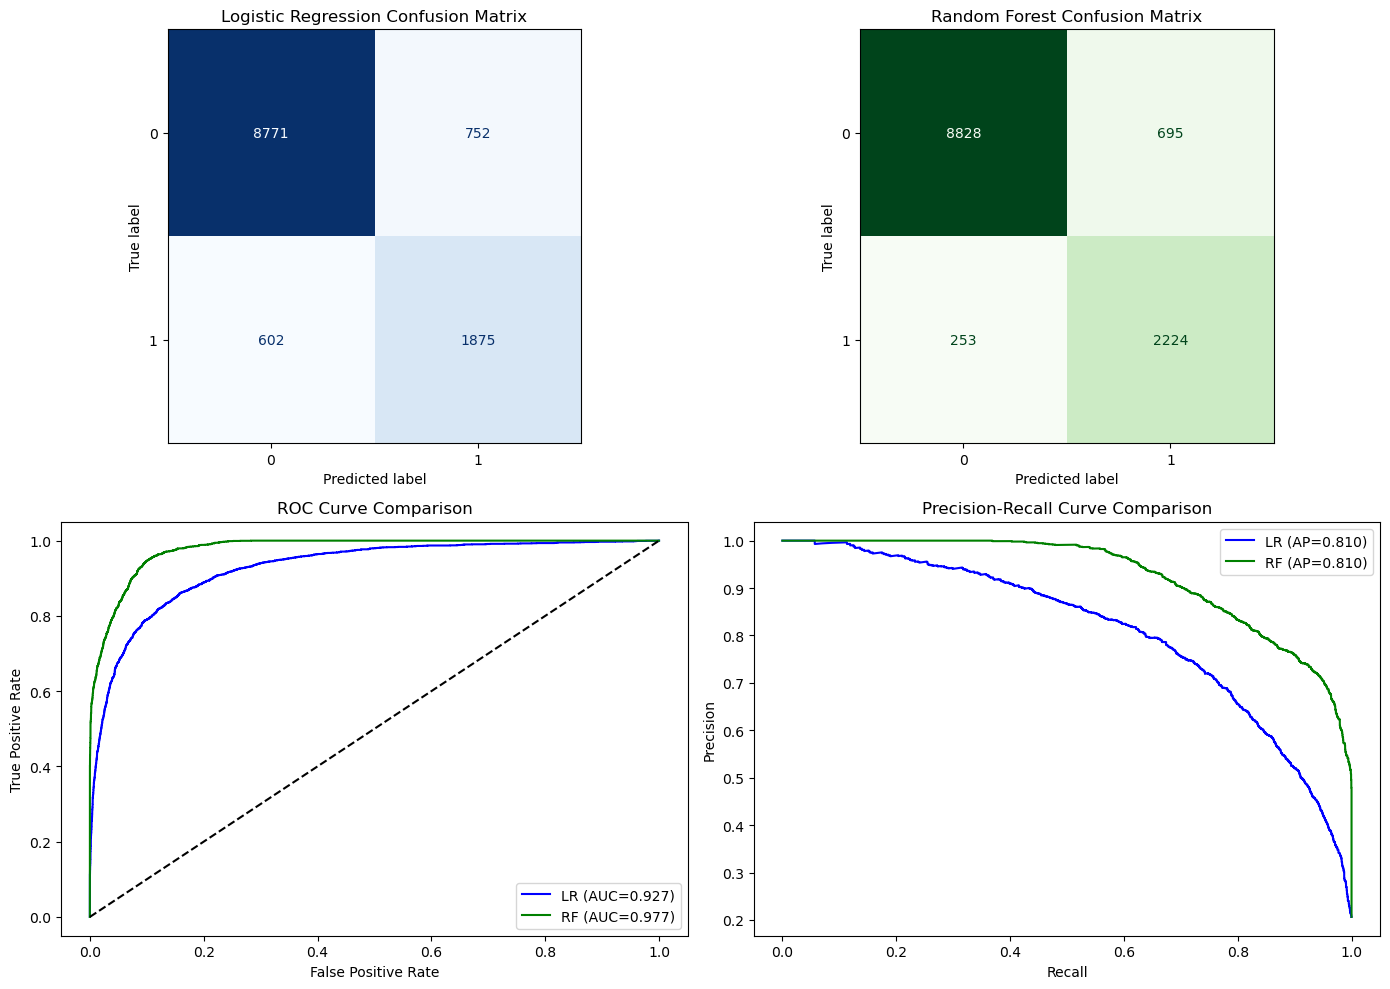

In [271]:
#Tuned thresholds predictions
y_probs_lr = log_reg_grid.best_estimator_.predict_proba(X_train)[:,1]
y_pred_lr = (y_probs_lr >= 0.346).astype(int)

y_probs_rf = rf_grid.best_estimator_.predict_proba(X_train)[:,1]
y_pred_rf = (y_probs_rf >= 0.307).astype(int)

#Confusion  Matrices
cm_lr = confusion_matrix(y_train, y_pred_lr)
cm_rf = confusion_matrix(y_train, y_pred_rf)

#ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_train, y_probs_lr)
auc_lr = roc_auc_score(y_train, y_probs_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_train, y_probs_rf)
auc_rf = roc_auc_score(y_train, y_probs_rf)

#Precision Recall Curves
prec_lr, rec_lr, _ = precision_recall_curve(y_train, y_probs_lr)
ap_lr = average_precision_score(y_train, y_probs_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_train, y_probs_rf)
ap_rf = average_precision_score(y_train, y_probs_rf)

#Dashboard Layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
axes[0,0].set_title("Logistic Regression Confusion Matrix")
ConfusionMatrixDisplay(cm_rf).plot(ax=axes[0,1], cmap="Greens", colorbar=False)
axes[0,1].set_title("Random Forest Confusion Matrix")

axes[1,0].plot(fpr_lr,tpr_lr, label=f"LR (AUC={auc_lr:.3f})", color="blue")
axes[1,0].plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})", color="green")
axes[1,0].plot([0,1],[0,1],'k--')
axes[1,0].set_xlabel("False Positive Rate")
axes[1,0].set_ylabel("True Positive Rate")
axes[1,0].set_title("ROC Curve Comparison")
axes[1,0].legend()

axes[1,1].plot(rec_lr, prec_lr, label=f"LR (AP={ap_lr:.3f})", color="blue")
axes[1,1].plot(rec_rf, prec_rf, label=f"RF (AP={ap_lr:.3f})", color="green")
axes[1,1].set_xlabel("Recall")
axes[1,1].set_ylabel("Precision")
axes[1,1].set_title("Precision-Recall Curve Comparison")
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [273]:
fig.savefig("model_comparison_dashboard.png", dpi=300, bbox_inches="tight")

In [279]:
joblib.dump(rf_grid.best_estimator_, "random_forest_pipeline.pkl")
best_threshold=0.307
joblib.dump(best_threshold, "rf_best_threshold.pkl")

['rf_best_threshold.pkl']